## Mod 6 Lecture 4 Data Challenge:  Simple Linear Regression

### Purpose

**Purpose**: Run a simple linear regression (SLR) on the NYC Yellow Taxi Dec 2023 excerpt to explain how a single input (X) relates to Tip % (Y). Practice picking a sensible X, fitting the line, and interpreting β₁, p‑value, and 95% confidence interval—plus basic assumption checks.

### Data
We are looking at ONE month's worth of data (December 2023 to be exact).  Remember the data dictionary is found [HERE](https://data.cityofnewyork.us/Transportation/2023-Yellow-Taxi-Trip-Data/4b4i-vvec/about_data)

### Instructor Guidance (10 Minutes)

#### Goals

- Pick an X with a plausible relationship to Tip % that is available at trip time.

- Communicate β₁ with units, p-vale, and a 95% CI.

#### Special considerations

- `Tip %` is `tip_amount / fare_amount`. Choosing `fare_amount` as X can create a built‑in relationship because it’s in the definition of Y (mathematical coupling). Encourage alternative X’s like `trip_distance`, `pickup_hour (as numeric)`, or `passenger_count`.

- Linearity check: Is the relationship roughly straight‑line? If X is discrete (e.g., passenger_count), SLR still works but discuss meaning.

- Intercept meaning: If X=0 is unrealistic (0 miles), say the intercept is just a mathematical anchor.

- Outliers: Large distances/fares can dominate. Consider trimming extremes thoughtfully or explaining how you would handle outliers.  

#### Critical thinking prompts as you work through the challenge (be prepared to answer at the end):

- Which input would you use to make a decision before the ride starts? Why?

- If β₁ is tiny but the p‑value is very small, is that useful for the business?

- If residuals (can only get residuals after fitting the model) "fan out" as X grows, what story might that tell about tipping behavior?

- Would your conclusion change if you looked at daytime vs. late night rides separately?

### Student Tasks (35 minutes)

Step 0 — Load Packages and Data, Fix Data Types, Create Tip % Column 

**Hint**:  You did this in the Code-Along, refer back to the notebook to help you!

In [1]:
# import packages
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:


df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures_Kevin/Mod6/data/2023_Yellow_Taxi_Trip_Data_20251015.csv', low_memory=False)
#12/01/2023 04:11:39 PM
#df['tpep_pickup_datetime'].head()
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], format="%m/%d/%Y %H:%M:%S %p")
df['hour'] = df['tpep_pickup_datetime'].dt.hour


# Coerce fare, tip, distance to numeric safely
num_cols = ['fare_amount', 'tip_amount', 'trip_distance']
for c in num_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
)

# Clean data some and add a new column called 'tip_pct' as the target 
df = df[(df['fare_amount'] > 0) & (df['tip_amount'] >= 0) & (df['trip_distance'] > 0)]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=num_cols)
df['tip_pct'] = df['tip_pct'] = 100 * df['tip_amount'] / df['fare_amount']

# Limit tip_pct from 0 to 100%
df = df[(df['tip_pct'] >= 0) & (df['tip_pct'] <= 100)]


Step 1 — Choose Your X (be sure to chose an X variable that would be available at trip time (not after the trip takes place))

Add a 2–3 sentence rationale in Markdown: Why could X relate to `tip_pct`? Why is it available **when the decision is made** (meaning driver has the information before the actual drive takes place)?

I choose to go with time of day for my x value. Time of day could have some correlation with tip percentage because maybe someone requesting a ride at a later time is willing to tip more. The driver knows the time of day before they decide to pick up the rider. 

In [15]:

X = df[['hour']]
y = df['tip_pct']
lin = LinearRegression().fit(X, y) #default fits intercept 
print('Intercept (β₀):', lin.intercept_)
print('Slope (β₁):', lin.coef_[0])

Intercept (β₀): 19.52945864607844
Slope (β₁): 0.05264676179961391


Step 2 — Quick Visual Check (Linearity & Outliers)

Add a 2-3 sentence rationale on how you would handle outliers or how you did handle outliers (if you handled them for this challenge).  Is the linear relationship there between your X and Y?  Is it a strong relationship?  What is the benefits of a strong relationship between X and Y?

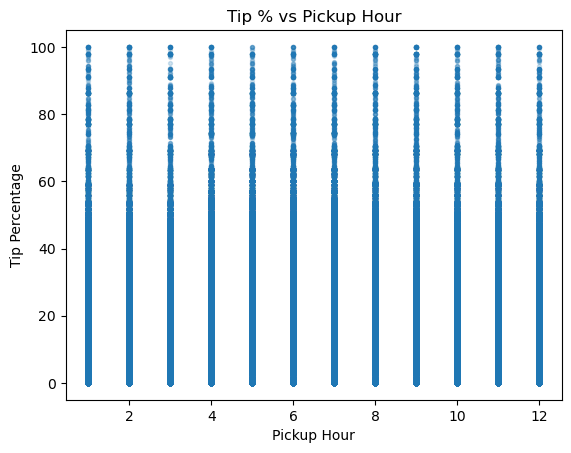

In [16]:
plt.figure()
plt.scatter(df['hour'], df['tip_pct'], alpha=0.2, s=8)
plt.xlabel('Pickup Hour')
plt.ylabel('Tip Percentage')
plt.title('Tip % vs Pickup Hour')
plt.show()

Step 3 — Fit SLR Model to Data

In [17]:
# Add constant to X for intercept
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm)
ols = model.fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                tip_pct   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     549.0
Date:                Wed, 29 Oct 2025   Prob (F-statistic):          2.11e-121
Time:                        20:34:41   Log-Likelihood:            -1.2914e+07
No. Observations:             3196455   AIC:                         2.583e+07
Df Residuals:                 3196453   BIC:                         2.583e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.5295      0.017   1137.768      0.0

Step 4 — Interpret the model's coefficients, p-values, and CI 

Double-click cell to type in your answer

Step 5 — Post‑Fit Assumption Glance 

Add 2-3 sentences about the residuals any curve? funnel shape? obvious outliers?  How would you go about checking if residuals were normally distributed?  

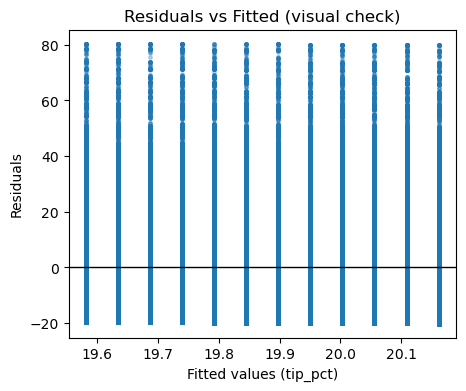

In [18]:
#RUN THIS CELL WITHOUT CHANGES
resid = ols.resid
fitted = ols.fittedvalues
plt.figure(figsize=(5,4))
plt.scatter(fitted, resid, s=6, alpha=0.3)
plt.axhline(0, color='k', lw=1)
plt.xlabel('Fitted values (tip_pct)')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (visual check)')
plt.show()

### Reflection (10-15 mins)

**In addition to the critical thinking questions at the top** of the notebook be prepared to discuss: 

- If you had to make a decision tomorrow, would this simple model be enough? Why/why not?

- What’s one different X you’d try next and why?

This model would not be enough to rely on. The model shows that the time of day has nearly no meaningful impact on tip percentage. 
One different X I would try next is trip distance. It is avaiable at trip distance and might better explain tipping pattenrs. For example longer trips could lead to higher total tips or tip percentage. 